# Example use-case: Cosmological gravitational-wave merger rate density

The original project this codebase was designed for was to calculate the cosmological binary black-hole (BHBH) gravitational-wave merger and supernova transient rate density ([Hendriks et al. 2023](https://doi.org/10.1093/mnras/stad2857)).
 
The following section will flesh out the steps to perform a similar calculation.

Several ingredients are necessary here:
- population-synthesis results that contain BHBH systems
- A cosmological star formation rate density

This convolution is an event-based convolution by integration.

In [1]:
import os
import pkg_resources
import copy

import h5py
import pandas as pd
import numpy as np
import astropy.units as u

from syntheticstellarpopconvolve import convolve
from syntheticstellarpopconvolve import default_convolution_config
from syntheticstellarpopconvolve.general_functions import temp_dir

TMP_DIR = temp_dir("notebooks", "notebook_example_GW_merger_rate_density", clean_path=True)
VERBOSITY = 0

Lets start with loading some data and see which metallicities are present. This data is generated by a grid-based population-synthesis evolution at a series of fixed metallicities.

This package contains a minimized version of the data for this usecase, but if the environment variable `EXAMPLE_DATA_USECASE_GW_FILENAME` points to the full dataset it will use that.

In [3]:
data_filename = os.getenv('EXAMPLE_DATA_USECASE_GW_FILENAME')
example_usecase_GW_events_filename = data_filename if data_filename is not None else pkg_resources.resource_filename(
    "syntheticstellarpopconvolve",
    "example_data/example_data_usecase_gw.h5"
)

example_usecase_GW_events_data = pd.read_hdf(example_usecase_GW_events_filename,  key='data/combined_dataframes')
example_usecase_GW_events_data['delay_time_values_in_years'] = example_usecase_GW_events_data['formation_time_values_in_years']+example_usecase_GW_events_data['merger_time_values_in_years']

#
print(example_usecase_GW_events_data.columns)
log10_metallicity_centers = np.log10(example_usecase_GW_events_data['metallicity'].unique())
print(log10_metallicity_centers)
stepsize = np.diff(log10_metallicity_centers)
log10_bin_edges = np.concatenate([log10_metallicity_centers[:-1]-stepsize/2, log10_metallicity_centers[-2:]+stepsize[:2]/2])

Index(['uuid', 'mass_1', 'zams_mass_1', 'mass_2', 'zams_mass_2',
       'stellar_type_1', 'stellar_type_2', 'metallicity', 'eccentricity',
       'period', 'zams_period', 'fallback_1', 'fallback_2', 'random_seed',
       'undergone_ppisn_1', 'undergone_ppisn_2', 'comenv_counter',
       'stable_rlof_counter', 'undergone_CE_with_HG_donor',
       'undergone_CE_with_MS_donor', 'formation_time_values_in_years',
       'merger_time_values_in_years', 'number_per_solar_mass_values',
       'local_index', 'delay_time_values_in_years'],
      dtype='object')
[-1.4        -1.62727273 -1.85454545 -2.08181818 -2.30909091 -2.53636364
 -2.76363636 -2.99090909 -3.21818182 -3.44545455 -3.67272727 -3.9       ]


Next up is to set up the star formation info. In this example we use a redshift-based cosmological starformation history, and an accompanying metallicity distribution, both described in [van Son et al. 2023](https://dx.doi.org/10.3847/1538-4357/acbf51). 

The metallicity distribution of [van Son et al. 2023](https://dx.doi.org/10.3847/1538-4357/acbf51) is defined in log Z, and thus we will need to either convert it to a different base, or provide our input metallicity values in log Z as well.

We will first display a high resolution version of this metallicity-dependent star formation rate history, and then configure it to our needs.

(39, 49)
(39,)
(49, 39)
(49,)


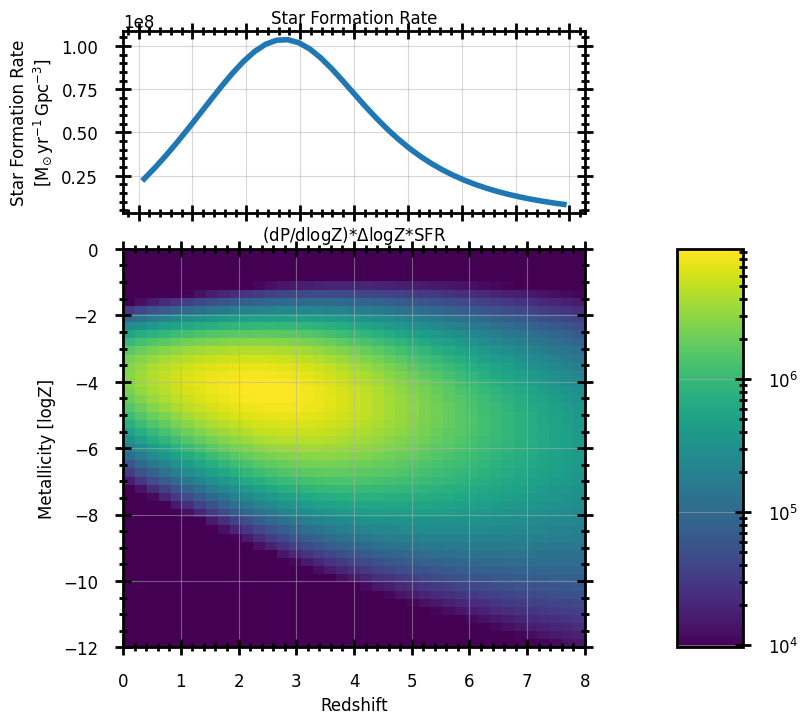

In [2]:
import matplotlib as plt
from syntheticstellarpopconvolve.starformation_rate_distributions import starformation_rate_distribution_vanSon2023
from syntheticstellarpopconvolve.metallicity_distributions import metallicity_distribution_vanSon2022
from syntheticstellarpopconvolve.general_functions import calculate_bincenters, calculate_bin_edges
from syntheticstellarpopconvolve.SFR_dict_plotting_routines import plot_sfr_dict

# Set up redshift bin info
redshift_bin_edges = np.linspace(0, 8, 40); redshift_bin_centers = calculate_bincenters(redshift_bin_edges)

# Set up metallicity bin info
log_metallicity_bin_edges = np.linspace(-12, 0, 50); log_metallicity_bin_centers = calculate_bincenters(log_metallicity_bin_edges)

#
sfr = starformation_rate_distribution_vanSon2023(redshift_bin_centers).to(u.Msun/u.yr/u.Gpc**3)

#
dpdlogZ = metallicity_distribution_vanSon2022(
    log_metallicity_centers=log_metallicity_bin_centers,
    redshifts=redshift_bin_centers,
)

print(dpdlogZ.shape)

high_res_sfr_dict = {
    "redshift_bin_edges": redshift_bin_edges,
    "starformation_rate_array": sfr,
    "metallicity_bin_edges": log_metallicity_bin_edges,
    "metallicity_distribution_array": dpdlogZ.T,  # We need to transpose!
}

axis_dict = plot_sfr_dict(
    high_res_sfr_dict,
    time_type="redshift",
    metallicity_string="logZ",
    metallicity_distribution_multiply_by_metallicity_bin_sizes=True,
    metallicity_distribution_multiply_by_sfr=True,
    metallicity_distribution_scale="log10",
    metallicity_distribution_cmap=copy.copy(plt.cm.viridis),
    return_axis_dict=True,
    figsize=(8,8),
    fontsize=12,
)

That looks good! Now lets set up our actual SFR dict and lets make sure that the metallicities in our dataset are expressed in log as well. We will let the (log) metallicity values of our data determine the metallicity bin values.

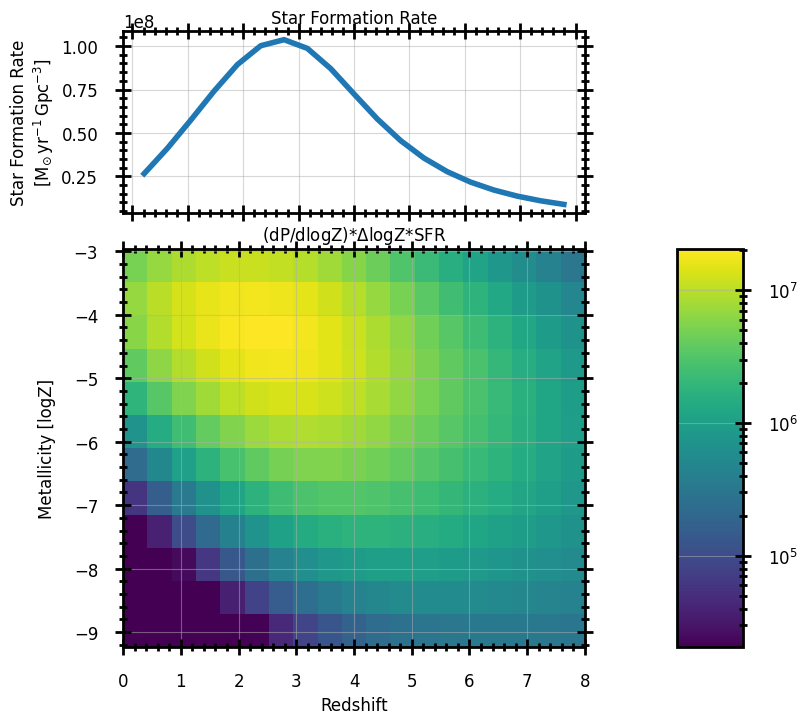

In [9]:
example_usecase_GW_events_data['log_metallicity'] = np.log(example_usecase_GW_events_data['metallicity'])

log_metallicity_bin_centers = np.sort(example_usecase_GW_events_data['log_metallicity'].unique())
log_metallicity_bin_edges = calculate_bin_edges(log_metallicity_bin_centers)

# Set up redshift bin info
redshift_bin_edges = np.linspace(0, 8, 20); redshift_bin_centers = calculate_bincenters(redshift_bin_edges)

#
sfr = starformation_rate_distribution_vanSon2023(redshift_bin_centers).to(u.Msun/u.yr/u.Gpc**3)

#
dpdlogZ = metallicity_distribution_vanSon2022(
    log_metallicity_centers=log_metallicity_bin_centers,
    redshifts=redshift_bin_centers,
)

sfr_dict = {
    "redshift_bin_edges": redshift_bin_edges,
    "starformation_rate_array": sfr,
    "metallicity_bin_edges": log_metallicity_bin_edges,
    "metallicity_distribution_array": dpdlogZ.T,  # We need to transpose!
}

axis_dict = plot_sfr_dict(
    sfr_dict,
    time_type="redshift",
    metallicity_string="logZ",
    metallicity_distribution_multiply_by_metallicity_bin_sizes=True,
    metallicity_distribution_multiply_by_sfr=True,
    metallicity_distribution_scale="log10",
    metallicity_distribution_cmap=copy.copy(plt.cm.viridis),
    return_axis_dict=True,
    figsize=(8,8),
    fontsize=12,
)

Now that we have set up the star formation information and loaded the input data, we can combine everything into the convolution config

In [16]:
# Assign filenames
input_hdf5_filename = os.path.join(TMP_DIR, "input_hdf5.h5")
output_hdf5_filename = os.path.join(TMP_DIR, "output_hdf5.h5")

# Open input file
input_hdf5_file = h5py.File(input_hdf5_filename, "w")

# Create groups main
input_hdf5_file.create_group("input_data")
input_hdf5_file.create_group("config")

# add group for events
input_hdf5_file.create_group("input_data/events")

# close
input_hdf5_file.close()

# store the data frame in the hdf5file
example_usecase_GW_events_data.to_hdf(input_hdf5_filename, key="input_data/events/example_GW_merger_rate_density")

# Some general configuration
convolution_config = copy.copy(default_convolution_config)
convolution_config["input_filename"] = input_hdf5_filename
convolution_config["output_filename"] = output_hdf5_filename
convolution_config["tmp_dir"] = TMP_DIR
convolution_config["redshift_interpolator_data_output_filename"] = os.path.join(
    TMP_DIR, "interpolator_dict.p"
)
convolution_config["multiply_by_time_binsize"] = False

# convolution instructions
convolution_config["convolution_instructions"] = [
    {
        "input_data_type": "event",
        "convolution_type": "integration",
        "input_data_name": "example_GW_merger_rate_density",
        "output_data_name": "intrinsic",
        "ignore_metallicity": False,
        "data_column_dict": {
            # required
            "normalized_yield": "number_per_solar_mass_values",
            "delay_time": {"column_name": "delay_time_values_in_years", "unit": u.yr},
        },
    },
]

#
convolution_config["time_type"] = "redshift"

# configure the target convolution times. In this case we only want to model the rate at redshift ~0, so its a simple set up
convolution_config["convolution_redshift_bin_edges"] = np.array([0, 0.25])

# # store
# convolution_config["SFR_info"] = sfr_dict

# input_hdf5_file = h5py.File(input_hdf5_filename, "r")

# # convolve
# convolve(config=convolution_config)


With the full datasets for .. availble on https://zenodo.org/records/8083112, and a better resolved convolution, we can recreate the following figures